# 03 Policy Simulation and Cost Scenarios
## 정책 시뮬레이션과 비용 시나리오

이 노트북은 risk score를 manual review policy로 변환한다.

핵심 질문은 Top-K review scope를 어디까지 넓히는 것이 default capture와 review burden 사이에서 가장 현실적인가이다.


## Setup
### 설정


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SAMPLE_DIR = DATA_DIR / "sample"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def read_table(name):
    path = TABLE_DIR / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

def as_percent(series, digits=2):
    return (series.astype(float) * 100).round(digits)


## Top-K review trade-off
### Top-K 리뷰 정책 비교

Top 1%, 5%, 10%, 17%, 20% 리뷰 범위에서 precision, capture rate, review workload를 비교한다.


,policy,review_count,tp,fp,weighted_fp,precision_pct,weighted_precision_pct,capture_rate_pct,lift
0,Top 1%,4590,4589,1,20,99.98,99.57,3.86,3.861152
1,Top 5%,22946,22742,204,4080,99.11,84.79,19.14,3.827659
2,Top 10%,45892,44326,1566,31320,96.59,58.60,37.30,3.730209
3,Top 15%,68837,63994,4843,96860,92.96,39.78,53.85,3.590285
4,Top 20%,91783,81176,10607,212140,88.44,27.68,68.31,3.415678


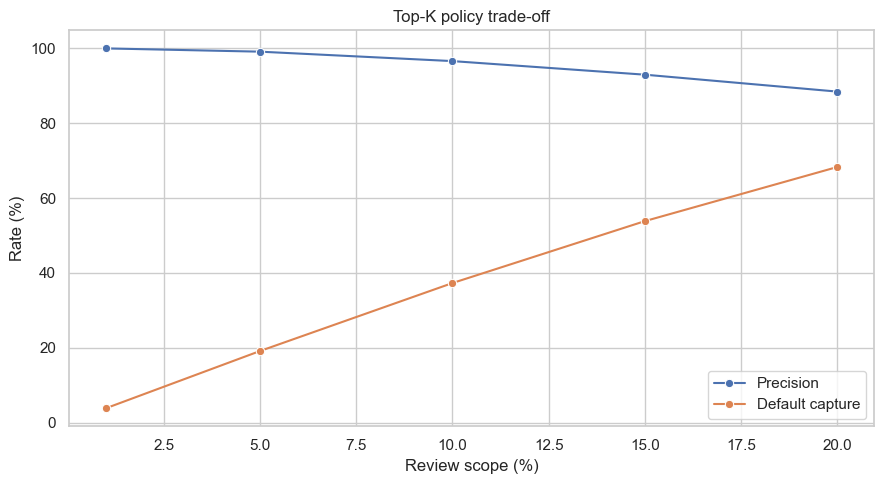

C:\Users\박동하\Documents\Codex\2026-05-04\files-mentioned-by-the-user-amex\amex-credit-risk-portfolio-public\outputs\figures\topk_policy_tradeoff_precision_capture.png


In [2]:
topk = read_table("topk_policy_tradeoff.csv")
weighted = read_table("weighted_policy_tradeoff.csv")

topk_view = topk.merge(
    weighted[["policy", "weighted_fp", "weighted_precision", "weighted_lift"]],
    on="policy",
    how="left",
)
for col in ["precision", "capture_rate", "weighted_precision"]:
    topk_view[f"{col}_pct"] = as_percent(topk_view[col])
display(
    topk_view[
        [
            "policy",
            "review_count",
            "tp",
            "fp",
            "weighted_fp",
            "precision_pct",
            "weighted_precision_pct",
            "capture_rate_pct",
            "lift",
        ]
    ]
)

plot_topk = topk_view.copy()
plot_topk["review_scope_pct"] = plot_topk["review_rate"] * 100
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=plot_topk, x="review_scope_pct", y="precision_pct", marker="o", ax=ax, label="Precision")
sns.lineplot(data=plot_topk, x="review_scope_pct", y="capture_rate_pct", marker="o", ax=ax, label="Default capture")
ax.set_title("Top-K policy trade-off")
ax.set_xlabel("Review scope (%)")
ax.set_ylabel("Rate (%)")
ax.legend()
path = save_figure("topk_policy_tradeoff_precision_capture.png")
plt.show()
print(path)


review scope를 넓히면 default capture는 증가하지만 precision은 낮아진다. 따라서 좋은 정책은 단순히 가장 많은 고객을 보는 것이 아니라, review cost와 missed default cost를 함께 고려해야 한다.


## Cost-sensitive net benefit
### 비용 민감 순효익

Conservative, Base, Aggressive 시나리오에서 review scope별 normalized net benefit을 비교한다.


,scenario,policy,review_rate,tp,fp,effective_review_count,avoided_loss,operating_cost_total,net_benefit
83,Aggressive,Top 28%,0.28,101611,26885,639311.0,21338.31,4271.955,17066.355
49,Base,Top 17%,0.17,71205,6811,207425.0,7120.50,2755.350,4365.150
9,Conservative,Top 4%,0.04,18245,112,20485.0,547.35,432.100,115.250


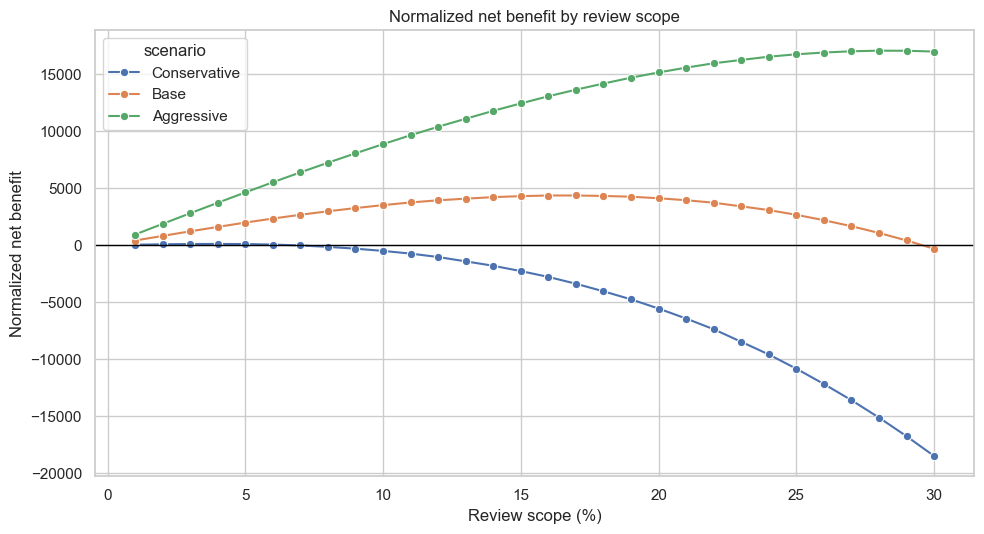

C:\Users\박동하\Documents\Codex\2026-05-04\files-mentioned-by-the-user-amex\amex-credit-risk-portfolio-public\outputs\figures\normalized_net_benefit_by_review_scope.png


In [3]:
net_benefit = read_table("normalized_net_benefit_by_review_scope.csv")
best_by_scenario = (
    net_benefit.sort_values("net_benefit", ascending=False)
    .groupby("scenario", as_index=False)
    .head(1)
    .sort_values("scenario")
)
display(
    best_by_scenario[
        [
            "scenario",
            "policy",
            "review_rate",
            "tp",
            "fp",
            "effective_review_count",
            "avoided_loss",
            "operating_cost_total",
            "net_benefit",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=net_benefit,
    x="review_scope_pct",
    y="net_benefit",
    hue="scenario",
    marker="o",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Normalized net benefit by review scope")
ax.set_xlabel("Review scope (%)")
ax.set_ylabel("Normalized net benefit")
path = save_figure("normalized_net_benefit_by_review_scope.png")
plt.show()
print(path)


Base scenario에서는 Top 17%가 가장 높은 normalized net benefit을 보인다. 이 값은 실제 이익이 아니라 exposure 정보가 없는 상황에서 정책 비교를 위한 정규화 지표이다.


## Final policy interpretation
### 최종 정책 해석

모델 점수는 자동 거절이 아니라 manual review 우선순위와 monitoring을 위한 decision-support signal로 사용한다.


In [4]:
base = net_benefit[net_benefit["scenario"].eq("Base")].sort_values("net_benefit", ascending=False)
recommended = base.iloc[0]
final_decision = pd.DataFrame(
    [
        {"item": "Score use", "decision": "Ranking-oriented manual review priority"},
        {"item": "Recommended Base threshold", "decision": recommended["policy"]},
        {"item": "Reason", "decision": "Highest normalized net benefit under Base scenario"},
        {"item": "Not intended for", "decision": "Automatic adverse action or calibrated PD disclosure"},
        {"item": "Required before production", "decision": "Calibration, drift, fairness, compliance, access control, audit logging"},
    ]
)
display(final_decision)


,item,decision
0,Score use,Ranking-oriented manual review priority
1,Recommended Base threshold,Top 17%
2,Reason,Highest normalized net benefit under Base scen...
3,Not intended for,Automatic adverse action or calibrated PD disc...
4,Required before production,"Calibration, drift, fairness, compliance, acce..."


최종 메시지는 예측 모델 자체가 아니라, 예측 점수를 운영 가능한 review policy로 번역했다는 점이다. 이 제한을 명확히 적어야 포트폴리오에서 과장되지 않고 신뢰감 있게 보인다.
